# **Step-1: Data Cleaning**

In [13]:
import pandas as pd

df = pd.read_excel("Global Superstore.xls")

df.info()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

np.int64(0)

**Convert Data**

In [14]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])

**Create New Columns**

In [15]:
df['Year']=df['Order Date'].dt.year
df['Month']=df['Order Date'].dt.month_name()
df['Quarter']=df['Order Date'].dt.quarter

**Delivery Time**

In [16]:
df['Delivery Days']=(
    df['Ship Date']-df['Order Date']
).dt.days

**Save cleaned data**

In [17]:
df.to_csv("Cleaned_Global_Superstore.csv",index=False)

# **STEP-2 : Exploratory Data Analysis**

In [18]:
print("Total Sales:")
display(df['Sales'].sum())

print("\nTotal Profit:")
display(df['Profit'].sum())

print("\nSales by Category:")
display(df.groupby('Category')['Sales'].sum())

print("\nSales by Product Name (Top 5):")
display(df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head())

print("\nMonthly Sales:")
monthly=df.groupby(
df['Order Date'].dt.to_period('M')
)['Sales'].sum()
display(monthly)

print("\nSales by Country (Top 5):")
display(df.groupby("Country")["Sales"].sum().sort_values(ascending=False).head())

Total Sales:


np.float64(12642501.909880001)


Total Profit:


np.float64(1467457.2912800002)


Sales by Category:


...

,Sales
Product Name,
"Apple Smart Phone, Full Size",86935.7786
"Cisco Smart Phone, Full Size",76441.5306
"Motorola Smart Phone, Full Size",73156.3030
"Nokia Smart Phone, Full Size",71904.5555
Canon imageCLASS 2200 Advanced Copier,61599.8240



Monthly Sales:


,Sales
Order Date,
2011-01,98898.48886
2011-02,91152.15698
2011-03,145729.36736
2011-04,116915.76418
2011-05,146747.83610
2011-06,215207.38022
2011-07,115510.41912
2011-08,207581.49122
2011-09,290214.45534



Sales by Country (Top 5):


,Sales
Country,
United States,2.297201e+06
Australia,9.252359e+05
France,8.589311e+05
China,7.005620e+05
Germany,6.288400e+05


In [19]:
#Total Sales
df['Sales'].sum()

np.float64(12642501.909880001)

In [20]:
#Total Profit
df['Profit'].sum()

np.float64(1467457.2912800002)

In [21]:
#Top Categories
df.groupby('Category')['Sales'].sum()

,Sales
Category,
Furniture,4.110874e+06
Office Supplies,3.787070e+06
Technology,4.744557e+06


In [22]:
#Top Products
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)

,Sales
Product Name,
"Apple Smart Phone, Full Size",86935.7786
"Cisco Smart Phone, Full Size",76441.5306
"Motorola Smart Phone, Full Size",73156.3030
"Nokia Smart Phone, Full Size",71904.5555
Canon imageCLASS 2200 Advanced Copier,61599.8240
...,...
Avery Hi-Liter Pen Style Six-Color Fluorescent Set,7.7000
Grip Seal Envelopes,7.0720
Xerox 20,6.4800


In [23]:
#Monthly Sales
monthly=df.groupby(
df['Order Date'].dt.to_period('M'))['Sales'].sum()
display(monthly)

,Sales
Order Date,
2011-01,98898.48886
2011-02,91152.15698
2011-03,145729.36736
2011-04,116915.76418
2011-05,146747.83610
2011-06,215207.38022
2011-07,115510.41912
2011-08,207581.49122
2011-09,290214.45534


In [24]:
#Country Sales
df.groupby("Country")["Sales"].sum()

,Sales
Country,
Afghanistan,21673.32000
Albania,3888.12000
Algeria,36091.59000
Angola,25554.00000
Argentina,57511.78328
...,...
Venezuela,26587.82956
Vietnam,65800.19940
Yemen,2465.71200


# **Step-3: Forecasting**

In [25]:
#Monthly Sales
monthly=df.groupby(
'Order Date'
)['Sales'].sum().reset_index()

Prepare Data for Forecasting

First, I'll aggregate the data to monthly sales to prepare it for time series forecasting. The `monthly` DataFrame currently has daily data, but forecasting for 6 months typically uses monthly granularity.

In [26]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()
monthly_sales = monthly_sales.set_index('Order Date')

display(monthly_sales.head())

,Sales
Order Date,
2011-01-01,98898.48886
2011-02-01,91152.15698
2011-03-01,145729.36736
2011-04-01,116915.76418
2011-05-01,146747.83610


Install and Import Libraries for Forecasting

I'll use the `statsmodels` library for the SARIMA model, which is well-suited for time series data with seasonality.

In [27]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

Apply SARIMA Model for Forecasting

I will apply a Seasonal Autoregressive Integrated Moving Average (SARIMA) model. I'll use common parameters `(1,1,1)` for the non-seasonal part and `(1,1,1,12)` for the seasonal part, assuming a yearly seasonality (12 months).

In [28]:
model = sm.tsa.statespace.SARIMAX(monthly_sales['Sales'],
                                order=(1, 1, 1),
                                seasonal_order=(1, 1, 1, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)

results = model.fit()

print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -249.911
Date:                            Sun, 09 Aug 2026   AIC                            509.822
Time:                                    10:59:18   BIC                            515.044
Sample:                                01-01-2011   HQIC                           510.955
                                     - 12-01-2014                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6742      0.342      1.971      0.049       0.004       1.345
ma.L1         -0.9300      0.154   

Generate 6-Month Forecast

Now I will use the fitted SARIMA model to predict sales for the next 6 months.

In [29]:
forecast_steps = 6
forecast = results.predict(start=len(monthly_sales), end=len(monthly_sales) + forecast_steps - 1)

# Create a date index for the forecast
last_date = monthly_sales.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')
forecast_series = pd.Series(forecast.values, index=forecast_index, name='Forecasted Sales')

display(forecast_series)

,Forecasted Sales
2015-01-01,350863.037239
2015-02-01,306263.461678
2015-03-01,350209.831484
2015-04-01,327129.020915
2015-05-01,396543.966754
2015-06-01,526179.850783


Visualize Actual and Forecasted Sales

Finally, I will plot the historical monthly sales alongside the 6-month forecast to create a dashboard view.

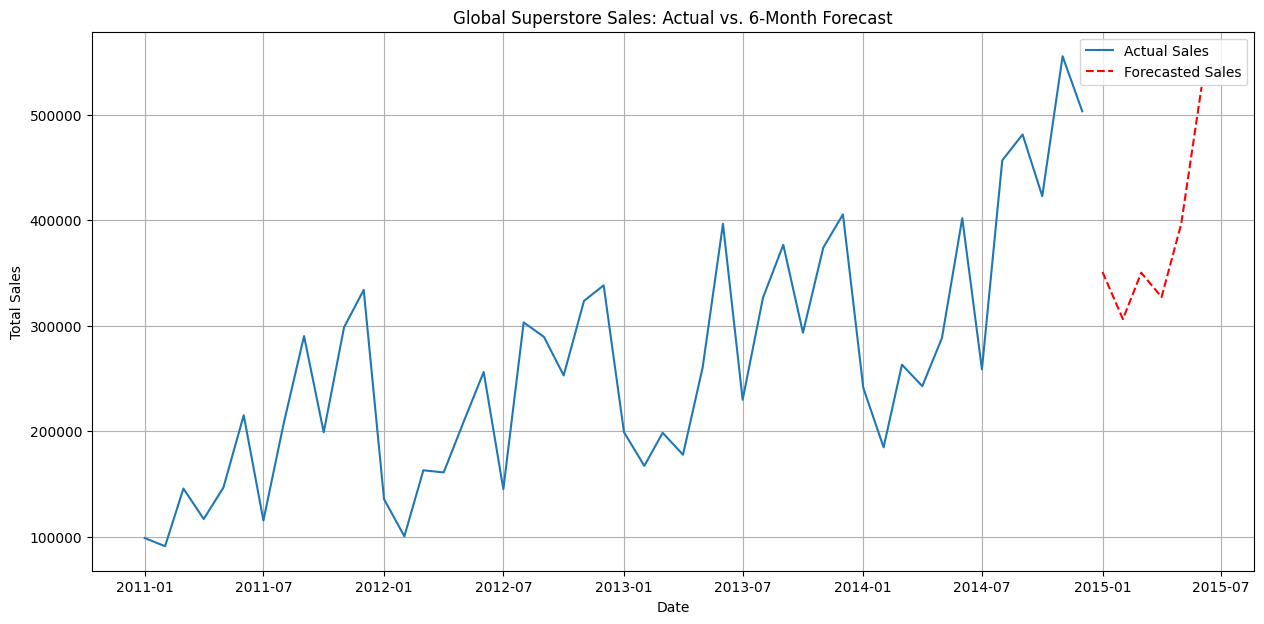

In [30]:
plt.figure(figsize=(15, 7))
plt.plot(monthly_sales.index, monthly_sales['Sales'], label='Actual Sales')
plt.plot(forecast_series.index, forecast_series, label='Forecasted Sales', color='red', linestyle='--')

plt.title('Global Superstore Sales: Actual vs. 6-Month Forecast')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()